In [1]:
%load_ext autoreload
%autoreload 2

# `import`

In [2]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import entropy

from tqdm import tqdm

from dice_rl_TU_Vienna.latex import latex_labels
from dice_rl_TU_Vienna.plot.general import plot_histogram
from dice_rl_TU_Vienna.plot.tabular import plot

from dice_rl_TU_Vienna.estimators.get import get_pv_s, get_gammas_log10
from dice_rl_TU_Vienna.estimators.tabular.test import test_auxiliary_estimates
from dice_rl_TU_Vienna.estimators.onpolicy import OnPE
from dice_rl_TU_Vienna.estimators.tabular.importance_sampling       import IS
from dice_rl_TU_Vienna.estimators.tabular.tabular_vafe              import TabularVafe
from dice_rl_TU_Vienna.estimators.tabular.tabular_dice              import TabularDice
from dice_rl_TU_Vienna.estimators.tabular.tabular_dual_dice         import TabularDualDice
from dice_rl_TU_Vienna.estimators.tabular.tabular_gradient_dice     import TabularGradientDice
from dice_rl_TU_Vienna.estimators.tabular.model_based_tabular_OffPE import AuxiliaryEstimates
from dice_rl_TU_Vienna.estimators.tabular.tabular_sarsa             import TabularSarsa

from dice_rl_TU_Vienna.utils.general import iterate_print
from dice_rl_TU_Vienna.utils.numpy import moving_average_N
from dice_rl_TU_Vienna.utils.seeds import set_all_seeds
from dice_rl_TU_Vienna.utils.json import json_get_id
from dice_rl_TU_Vienna.utils.bedtime import computer_sleep

from dice_rl_TU_Vienna.plugins.d3rlpy.dataset import convert_dataset

/Users/richardweiss/Documents/.venvs/dice_rl_TU_Vienna/lib/python3.11/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(
/Users/richardweiss/Documents/.venvs/dice_rl_TU_Vienna/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2025-05-30 10:33.14 [info     ] Register Shimmy environments. 


# Prepare

In [3]:
dir_data   = os.path.join("data",   "sepsis", "komorowski")
dir_images = os.path.join("images", "sepsis", "komorowski")

In [4]:
kinds = ["behavior", "evaluation"]

In [5]:
dir_evaluation = {
    kind: os.path.join(dir_data, kind)
        for kind in kinds
}

In [6]:
split = pd.read_parquet( os.path.join(dir_data, "split.parquet") )

In [7]:
split.head(50)

,bloc,icustayid,state,action,outcome,reward,model_probs,phys_probs
0,1,30000484,135,0,1,0,"[0.00041666667675599456, 0.0004166666767559945...","[0.7194280028343201, 0.0020000003278255463, 0...."
1,2,30000484,95,20,1,0,"[0.00041666667675599456, 0.0004166666767559945...","[0.8369070887565613, 0.0004999999655410647, 0...."
2,3,30000484,317,20,1,0,"[0.00041666667675599456, 0.0004166666767559945...","[0.08652101457118988, 0.005000000353902578, 0...."
3,4,30000484,317,20,1,0,"[0.00041666667675599456, 0.0004166666767559945...","[0.08652101457118988, 0.005000000353902578, 0...."
4,5,30000484,317,16,1,0,"[0.00041666667675599456, 0.0004166666767559945...","[0.08652101457118988, 0.005000000353902578, 0...."
5,6,30000484,317,11,1,0,"[0.00041666667675599456, 0.0004166666767559945...","[0.08652101457118988, 0.005000000353902578, 0...."
6,7,30000484,298,11,1,0,"[0.00041666667675599456, 0.0004166666767559945...","[0.07615385204553604, 0.0016666668234393, 0.00..."
7,8,30000484,399,16,1,0,"[0.00041666667675599456, 0.9900000095367432, 0...","[0.037931036204099655, 0.001896551693789661, 0..."
8,9,30000484,298,1,1,0,"[0.00041666667675599456, 0.0004166666767559945...","[0.07615385204553604, 0.0016666668234393, 0.00..."
9,10,30000484,148,1,1,0,"[0.00041666667675599456, 0.9900000095367432, 0...","[0.774196207523346, 0.0026975476648658514, 0.0..."


In [8]:
n_obs = split["state"] .max() + 1
n_act = split["action"].max() + 1

n_obs, n_act

(752, 25)

In [9]:
absorbing_states = [750, 751]

for i in range( len(split) ):
    if split.at[i, "state"] in absorbing_states:
        split.at[i, "model_probs"] = np.ones(n_act) / n_act
        split.at[i, "phys_probs"]  = np.ones(n_act) / n_act

In [10]:
# make_deterministic = lambda x: np.where( x < 0.0005, 0, np.where(x > 0.99, 1, x), )
# split["model_probs"] = split["model_probs"].apply(make_deterministic) # type: ignore

In [11]:
def get_dataset(split, padding=False, seed=None, overwrite=False):
    set_all_seeds(seed)

    path = os.path.join(dir_data, "dataset.parquet")
    if os.path.exists(path) and not overwrite: return pd.read_parquet(path)

    dataset = {
        "id": [],
        "t": [],
        "obs_init": [],
        "obs": [],
        "act": [],
        "rew": [],
        "obs_next": [],
        "probs_init": [],
        "probs_init_behavior": [],
        "probs": [],
        "probs_behavior": [],
        "probs_next": [],
        "probs_next_behavior": [],
    }

    for i in range(len(split)):
        id = split.loc[i, "icustayid"]
        t  = split.loc[i, "bloc"] - 1 # type: ignore

        if i == 0 or split.loc[i-1, "icustayid"] != id:
            obs_init            = split.loc[i, "state"]
            probs_init          = split.loc[i, "model_probs"]
            probs_init_behavior = split.loc[i, "phys_probs"]

        if i == len(split) - 1 or split.loc[i+1, "icustayid"] != id:
            if not padding: continue

            obs = split.loc[i, "state"]
            act = np.random.choice( range(n_act), p=split.loc[i, "phys_probs"], )
            rew = 0
            obs_next = obs

            probs          = split.loc[i, "model_probs"]
            probs_behavior = split.loc[i, "phys_probs"]
            probs_next = probs
            probs_next_behavior = probs_behavior

        else:
            obs      = split.loc[i, "state"]
            act      = split.loc[i, "action"]
            rew      = split.loc[i+1, "reward"]
            obs_next = split.loc[i+1, "state"]

            probs               = split.loc[i, "model_probs"]
            probs_behavior      = split.loc[i, "phys_probs"]
            probs_next          = split.loc[i+1, "model_probs"]
            probs_next_behavior = split.loc[i+1, "phys_probs"]

        dataset["id"].append(id)
        dataset["t"] .append(t)

        dataset["obs_init"].append(obs_init)
        dataset["obs"]     .append(obs)
        dataset["act"]     .append(act)
        dataset["rew"]     .append(rew)
        dataset["obs_next"].append(obs_next)

        dataset["probs_init"]         .append(probs_init)
        dataset["probs_init_behavior"].append(probs_init_behavior)
        dataset["probs"]              .append(probs)
        dataset["probs_behavior"]     .append(probs_behavior)
        dataset["probs_next"]         .append(probs_next)
        dataset["probs_next_behavior"].append(probs_next_behavior)

    dataset = pd.DataFrame(dataset)
    dataset.to_parquet(path)

    return dataset

In [12]:
def dataset_evluation_to_behavior(df):
    column_names = [
        "id", "t",
        "obs_init", "obs", "act", "rew", "obs_next",
        "probs_init_behavior", "probs_behavior", "probs_next_behavior",
    ]
    rename_columns = {
        "probs_init_behavior": "probs_init",
        "probs_behavior": "probs",
        "probs_next_behavior": "probs_next",
    }

    return df[column_names].rename(columns=rename_columns)

In [13]:
dataset = {}

x = get_dataset(split, padding=True, seed=0)
y = dataset_evluation_to_behavior(x)

dataset["evaluation"] = x
dataset["behavior"]   = y

In [14]:
auxiliary_estimates = {
    kind: AuxiliaryEstimates(
        dataset[kind],
        n_obs, n_act,
        dir_evaluation[kind],
        verbosity=1,
    )
        for kind in iterate_print(kinds, "kind")
}

kind=behavior
trying to load auxiliary estimates from data/sepsis/komorowski/behavior
loaded data/sepsis/komorowski/behavior/d0_bar.npy
loaded data/sepsis/komorowski/behavior/dD_bar.npy
loaded data/sepsis/komorowski/behavior/P_bar.npy
loaded data/sepsis/komorowski/behavior/r_bar.npy
loaded data/sepsis/komorowski/behavior/n.npy
kind=evaluation
trying to load auxiliary estimates from data/sepsis/komorowski/evaluation
loaded data/sepsis/komorowski/evaluation/d0_bar.npy
loaded data/sepsis/komorowski/evaluation/dD_bar.npy
loaded data/sepsis/komorowski/evaluation/P_bar.npy
loaded data/sepsis/komorowski/evaluation/r_bar.npy
loaded data/sepsis/komorowski/evaluation/n.npy


In [15]:
estimators = { kind: {} for kind in kinds }

print("OnPE")
kind = "behavior"
print(f"{kind=}")
label = "OnPE"
estimators[kind][label] = OnPE(dataset[kind])

print("IS")
kind = "evaluation"
print(f"{kind=}")
label = "IS"
estimators[kind][label] = IS(dataset[kind])

print("DICE")
for kind in iterate_print(kinds, "kind"):
    for estimator_type in [
        TabularVafe, TabularDice, TabularDualDice, TabularGradientDice, ]:

        estimator = estimator_type(
            dataset[kind],
            n_obs,
            n_act,
            dir_evaluation[kind],
            verbosity=1,
            auxiliary_estimates=auxiliary_estimates[kind],
        )

        estimators[kind][estimator.__name__] = estimator

OnPE
kind='behavior'
IS
kind='evaluation'
DICE
kind=behavior
kind=evaluation


In [16]:
estimators

{'behavior': {'OnPE': <dice_rl_TU_Vienna.estimators.onpolicy.OnPE at 0x304bf8bd0>,
  'TabularVafe': <dice_rl_TU_Vienna.estimators.tabular.tabular_vafe.TabularVafe at 0x301fc9090>,
  'TabularDice': <dice_rl_TU_Vienna.estimators.tabular.tabular_dice.TabularDice at 0x167eb7cd0>,
  'TabularDualDice': <dice_rl_TU_Vienna.estimators.tabular.tabular_dual_dice.TabularDualDice at 0x304bf9110>,
  'TabularGradientDice': <dice_rl_TU_Vienna.estimators.tabular.tabular_gradient_dice.TabularGradientDice at 0x30081c810>},
 'evaluation': {'IS': <dice_rl_TU_Vienna.estimators.tabular.importance_sampling.IS at 0x304bb6910>,
  'TabularVafe': <dice_rl_TU_Vienna.estimators.tabular.tabular_vafe.TabularVafe at 0x177b81410>,
  'TabularDice': <dice_rl_TU_Vienna.estimators.tabular.tabular_dice.TabularDice at 0x304bee1d0>,
  'TabularDualDice': <dice_rl_TU_Vienna.estimators.tabular.tabular_dual_dice.TabularDualDice at 0x304bee910>,
  'TabularGradientDice': <dice_rl_TU_Vienna.estimators.tabular.tabular_gradient_dice.T

# `get_pvs`

In [ ]:
gammas = get_gammas_log10()

projected = True
modified = True
lamda = 1e-6

## Discounted

In [18]:
pvs = { kind: {} for kind in kinds }

In [19]:
kind = "behavior"
label = "OnPE"

pvs[kind][label] = get_pv_s(
    estimator_s=estimators[kind]["OnPE"],
    gamma_s=gammas,
)

In [20]:
kind = "evaluation"
label = "IS"

pvs[kind][label] = {}

for weighted in [False, True]:
    print(f"{weighted=}")
    pvs[kind][label][weighted] = get_pv_s(
        estimator_s=estimators[kind][label],
        gamma_s=gammas,
        weighted=weighted,
    )

weighted=False
weighted=True


In [21]:
for kind in iterate_print(kinds, "kind"):
    dir = dir_evaluation[kind]

    label = "TabularVafe"
    print(label)
    file = os.path.join(dir, f"pvs_{label}.npy")

    if os.path.exists(file):
        arr = np.load(file)
    else:
        arr = get_pv_s(
            estimator_s=estimators[kind][label],
            gamma_s=gammas,
            projected=projected, weighted=None,
            modified=modified, lamda=lamda,
            verbosity=2,
        )
        np.save(file, arr)

    pvs[kind][label] = arr

    for label in [
        "TabularDice", "TabularDualDice", "TabularGradientDice"]:

        print(label)
        pvs[kind][label] = {}

        for weighted, postfix in zip([False, True], ["simple", "weighted"]):
            print(f"{weighted=}")

            file = os.path.join(dir, f"pvs_{label}_{postfix}.npy")

            if os.path.exists(file):
                arr = np.load(file)
            else:
                arr = get_pv_s(
                    estimators[kind][label],
                    gammas,
                    projected=projected, weighted=weighted,
                    modified=modified, lamda=lamda,
                    verbosity=2,
                )
                np.save(file, arr)

            pvs[kind][label][weighted] = arr

kind=behavior
TabularVafe
TabularDice
weighted=False
weighted=True
TabularDualDice
weighted=False
weighted=True
TabularGradientDice
weighted=False
weighted=True
kind=evaluation
TabularVafe
TabularDice
weighted=False
weighted=True
TabularDualDice
weighted=False
weighted=True
TabularGradientDice
weighted=False
weighted=True


In [22]:
pvs

{'behavior': {'OnPE': array([2.03706352e+00, 1.67966535e+00, 1.18407071e+00, 7.58481026e-01,
         4.59373794e-01, 2.69408784e-01, 1.55135467e-01, 8.84127877e-02,
         5.00936588e-02, 2.82892551e-02, 1.59461521e-02, 8.97920126e-03,
         5.05318171e-03, 2.84281718e-03, 1.59901455e-03, 8.99312456e-04,
         5.05758667e-04]),
  'TabularVafe': array([2.05317908e+00, 1.44523297e+00, 9.43223546e-01, 5.82248494e-01,
         3.46291184e-01, 2.01222452e-01, 1.15310154e-01, 6.55442961e-02,
         3.70833799e-02, 2.09253483e-02, 1.17900189e-02, 6.63725534e-03,
         3.73469629e-03, 2.10089994e-03, 1.18165251e-03, 6.64564685e-04,
         3.73735162e-04]),
  'TabularDice': {False: array([2.05317908e+00, 1.44523297e+00, 9.43223546e-01, 5.82248494e-01,
          3.46291184e-01, 2.01222452e-01, 1.15310154e-01, 6.55442961e-02,
          3.70833799e-02, 2.09253483e-02, 1.17900189e-02, 6.63725534e-03,
          3.73469629e-03, 2.10089994e-03, 1.18165251e-03, 6.64564685e-04,
         

## Undiscounted

In [23]:
pv = { kind: {} for kind in kinds }

In [24]:
kind = "behavior"
label = "OnPE"

pv[kind][label] = get_pv_s(
    estimator_s=estimators[kind]["OnPE"],
    gamma_s=1.0,
    scale=False,
)

In [25]:
kind = "evaluation"
label = "IS"

pv[kind][label] = {}

for weighted in [False, True]:
    print(f"{weighted=}")
    pv[kind][label][weighted] = get_pv_s(
        estimator_s=estimators[kind][label],
        gamma_s=1.0,
        weighted=weighted,
        scale=False,
    )

weighted=False
weighted=True


In [26]:
pv

{'behavior': {'OnPE': 50.580763767025985},
 'evaluation': {'IS': {False: 436.9883606551579, True: 99.99953307132922}}}

# Plot

## Policy Values

In [27]:
def plot_pvs_sepsis_komorowski(kind, weighted):

    plot_infos = []

    plot_infos += [
        {
            "x": 0.99,
            "label": "gamma=0.99",
            "color": "black",
            "marker": None,
        }
    ]

    if kind == "behavior":
        plot_infos += [
            {
                "y": pv[kind]["OnPE"],
                "label": None,
                "color": "lightgrey",
                "marker": "v",
            },
        ]
    if kind == "evaluation":
        plot_infos += [
            {
                "y": pv[kind]["IS"][weighted],
                "label": None,
                "color": "pink" if not weighted else "deeppink",
                "marker": "+" if not weighted else "x",
            },
        ]

    if kind == "behavior":
        plot_infos += [
            {
                "x": gammas,
                "y": pvs[kind]["OnPE"],
                "label": "OnPE",
                "color": "lightgrey",
                "marker": "v",
            },
        ]
    plot_infos += [
        {
            "x": gammas,
            "y": pvs[kind]["TabularVafe"],
            "label": "TabularVafe",
            "color": "blue",
            "marker": "1",
        },
        {
            "x": gammas,
            "y": pvs[kind]["TabularDice"][weighted],
            "label": "TabularDice",
            "color": "orange",
            "marker": "2",
        },
        {
            "x": gammas,
            "y": pvs[kind]["TabularDualDice"][weighted],
            "label": "TabularDualDice",
            "color": "green",
            "marker": "3",
        },
        {
            "x": gammas,
            "y": pvs[kind]["TabularGradientDice"][weighted],
            "label": f"TabularGradientDice, lamda={lamda}",
            "color": "red",
            "marker": "4",
        },
    ]
    if kind == "evaluation":
        plot_infos += [
            {
                "x": gammas,
                "y": pvs[kind]["IS"][weighted],
                "label": "SIS" if not weighted else "WIS",
                "color": "pink" if not weighted else "deeppink",
                "marker": "+" if not weighted else "x",
            },
        ]

    suptitle = f"Sepsis Komorowski - {kind} - PVs" + "\n" + f"{projected=}, {weighted=}"

    one_minus_gamma = True
    scale_pv = True

    xlabel = None
    ylabel = latex_labels["pv_scaled"]()

    xlim = None
    ylim = (0, 110)

    scale_x = True
    scale_y = False

    legend = { "loc": "upper right", }
    dir = dir_images

    plot(
        plot_infos,
        suptitle,
        one_minus_gamma, scale_pv,
        xlabel, ylabel,
        xlim, ylim,
        scale_x, scale_y,
        legend, # type: ignore
        dir,
    )

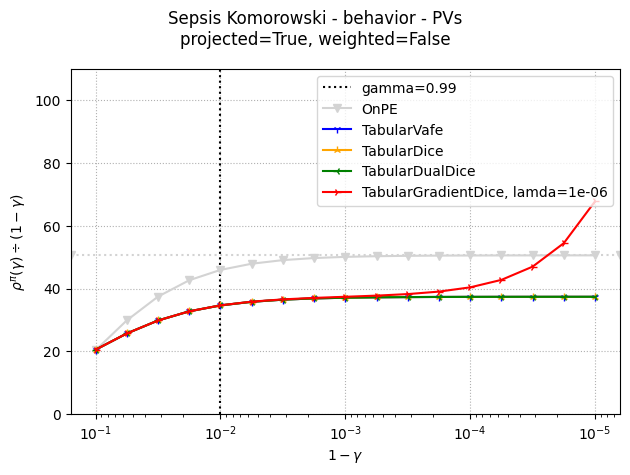

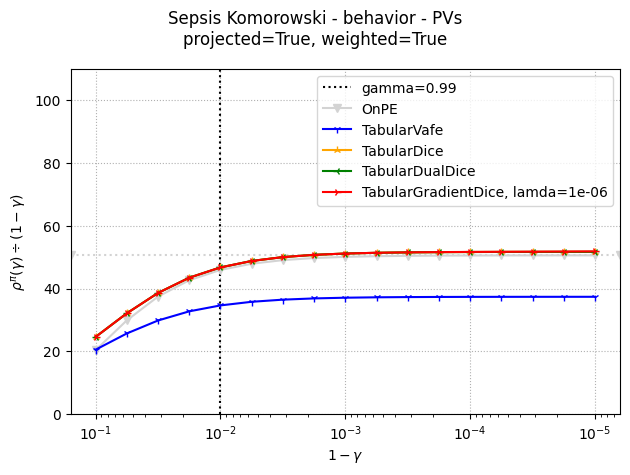

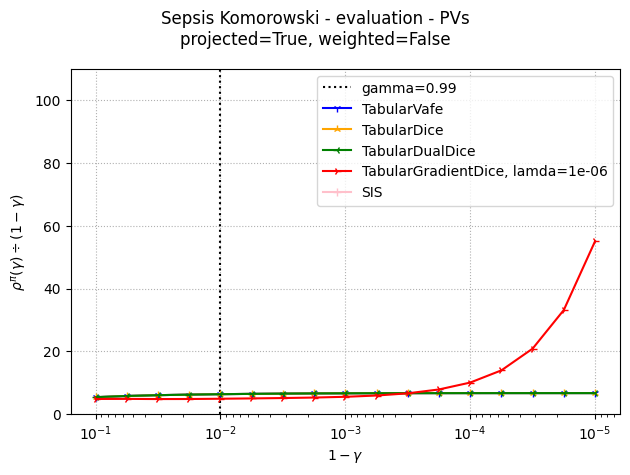

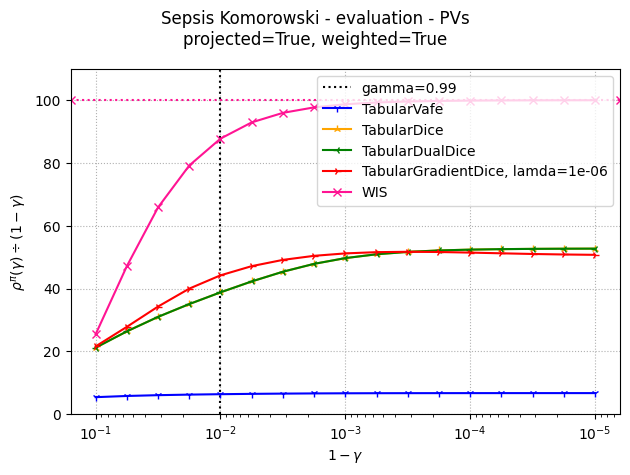

In [28]:
for kind in kinds:
    for weighted in [False, True]:
        plot_pvs_sepsis_komorowski(kind, weighted)

# Supplementary

## Policy Ratios

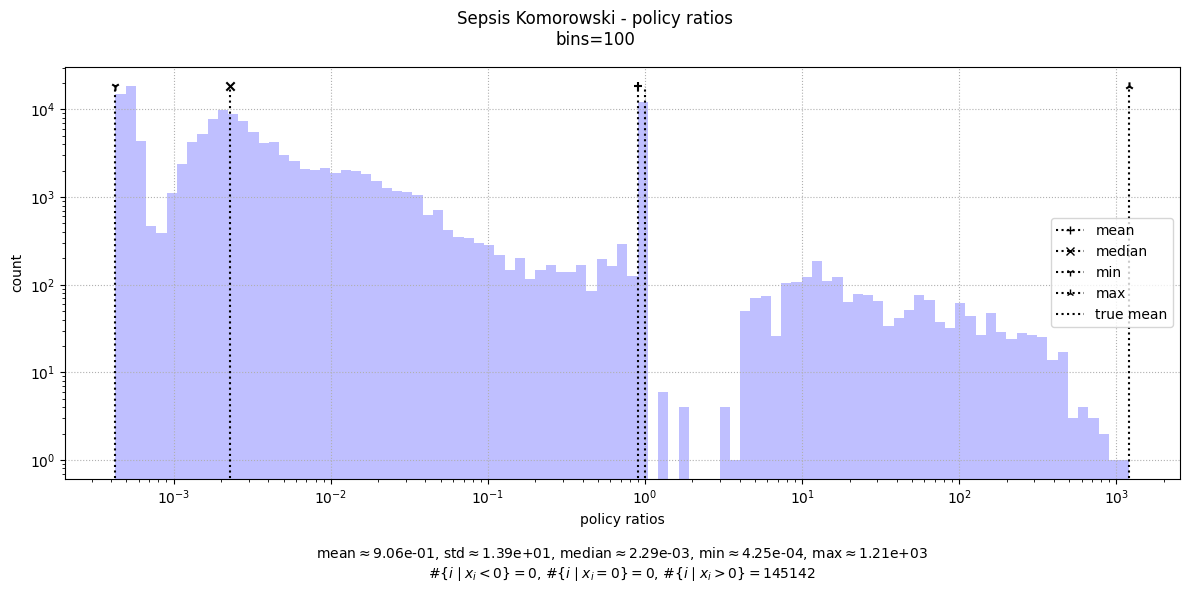

In [34]:
plot_histogram(
    data=estimators["evaluation"]["IS"].q, bins=100, moving_average_radius=None,
    suptitle=f"Sepsis Komorowski - policy ratios", xlabel="policy ratios",
    xscale=True, yscale=True,
    true_mean=1,
    dir=dir_images,
)

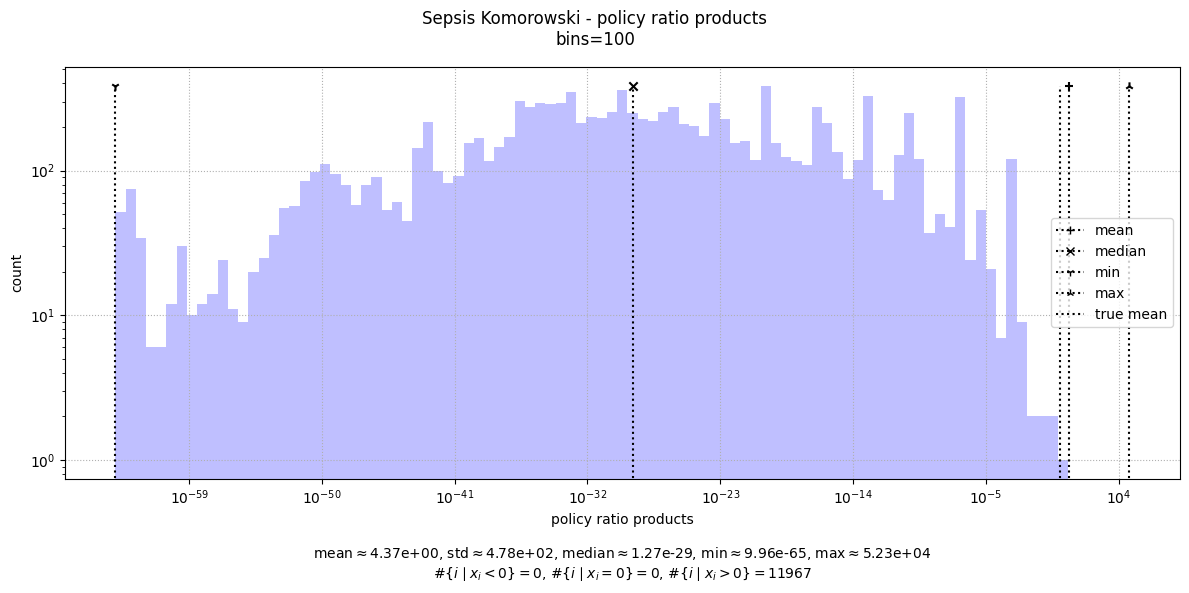

In [35]:
plot_histogram(
    data=estimators["evaluation"]["IS"].W, bins=100,
    suptitle=f"Sepsis Komorowski - policy ratio products", xlabel="policy ratio products",
    xscale=True, yscale=True,
    true_mean=1,
    dir=dir_images,
)

## `AuxiliaryEstimates`

In [36]:
def test_auxiliary_estimates_sepsis_komorowski(kind):
    test_auxiliary_estimates(
        auxiliary_estimates=auxiliary_estimates[kind],
        title_prefix=f"Sepsis Komorowski - {kind}",
        dir=os.path.join(dir_images, "auxiliary_estimates"),
        epsilon=0.1,
    )

# (s, a) visited:
{'absolute': 9083, 'relative': 0.4831382978723404}
# (s, a) not visited:
{'absolute': 9717, 'relative': 0.5168617021276596}

#{i: dD_bar[i] == 0, P_bar[i, :] != 0} = 0
#{i: dD_bar[i] == 0, P_bar[:, i] != 0} = 557825
#{i: dD_bar[i] == 0, d0_bar[i] != 0} = 9226

# ---------------------------------------------------------------- # 



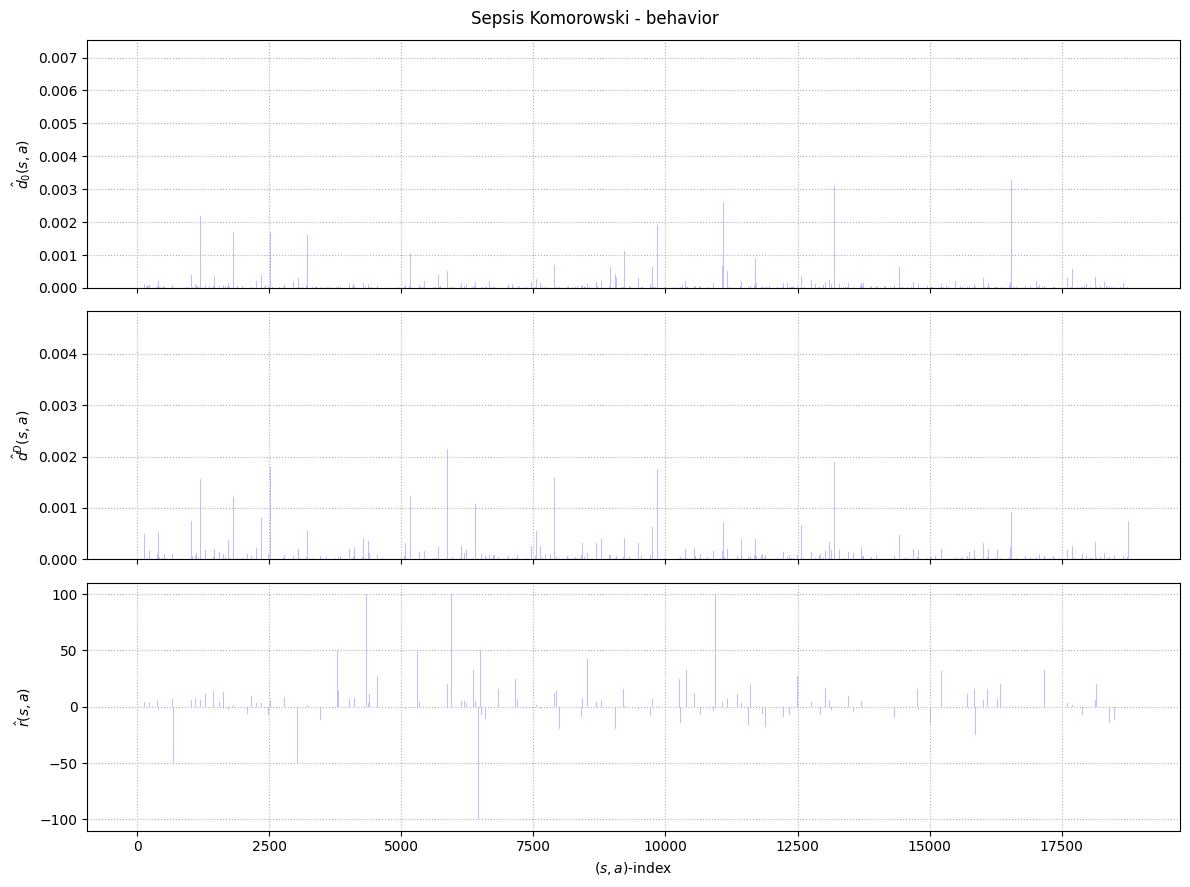

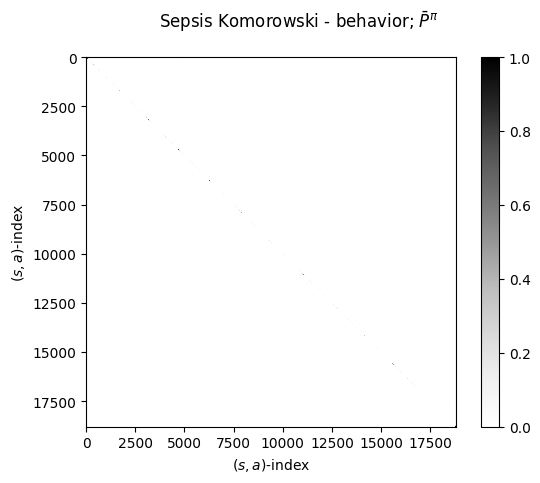

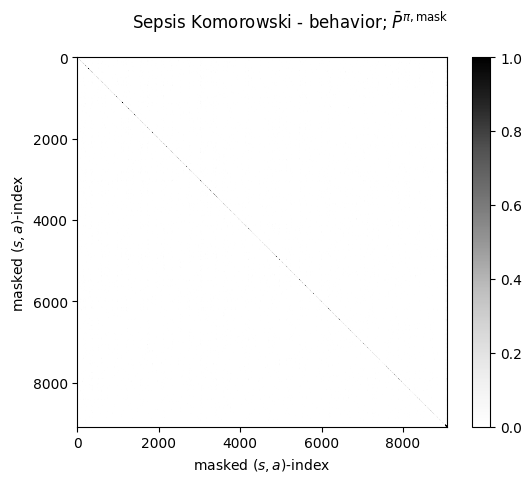

# ---------------------------------------------------------------- # 



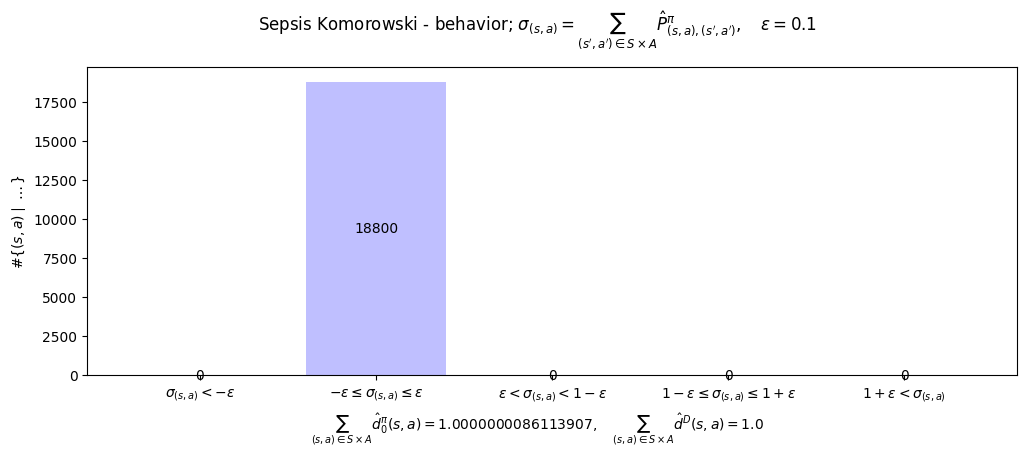

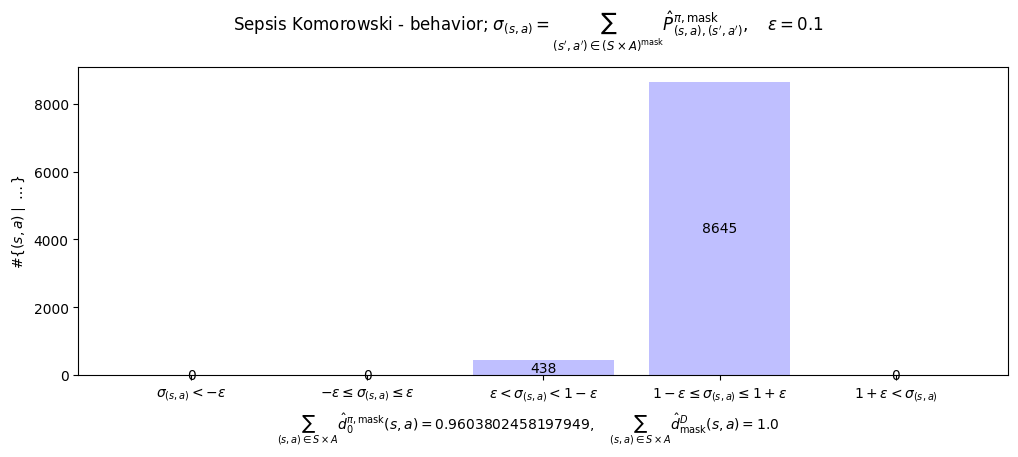

# ---------------------------------------------------------------- # 



In [37]:
test_auxiliary_estimates_sepsis_komorowski("behavior")

# (s, a) visited:
{'absolute': 9083, 'relative': 0.4831382978723404}
# (s, a) not visited:
{'absolute': 9717, 'relative': 0.5168617021276596}

#{i: dD_bar[i] == 0, P_bar[i, :] != 0} = 0
#{i: dD_bar[i] == 0, P_bar[:, i] != 0} = 557825
#{i: dD_bar[i] == 0, d0_bar[i] != 0} = 9226

# ---------------------------------------------------------------- # 



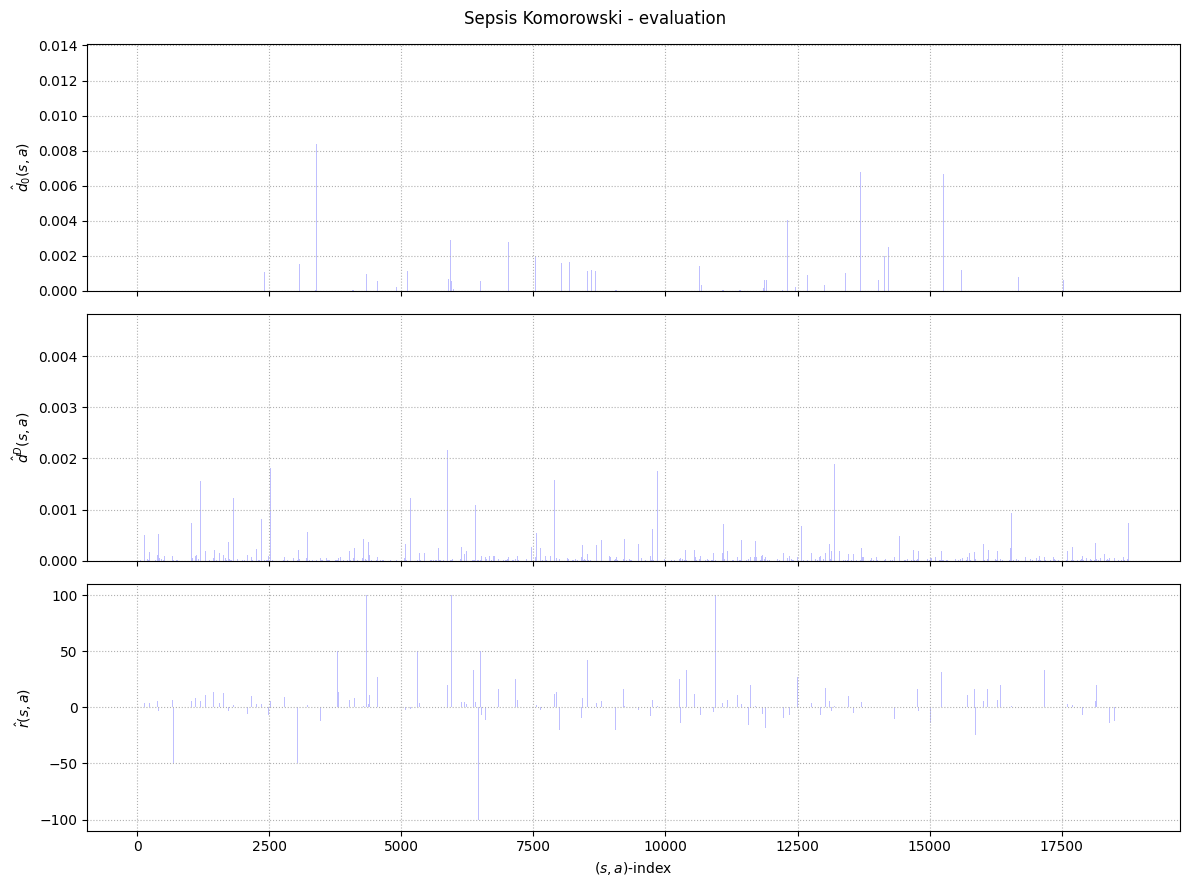

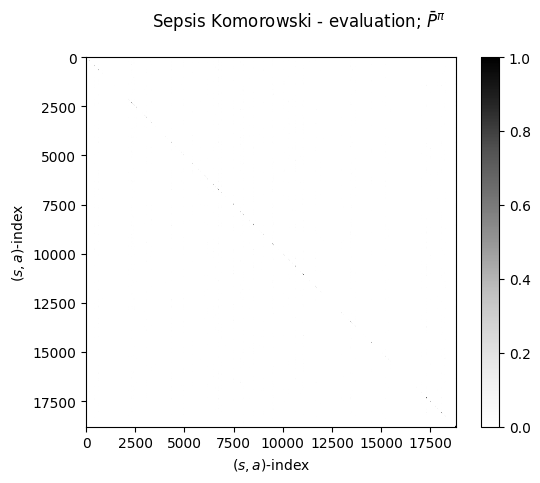

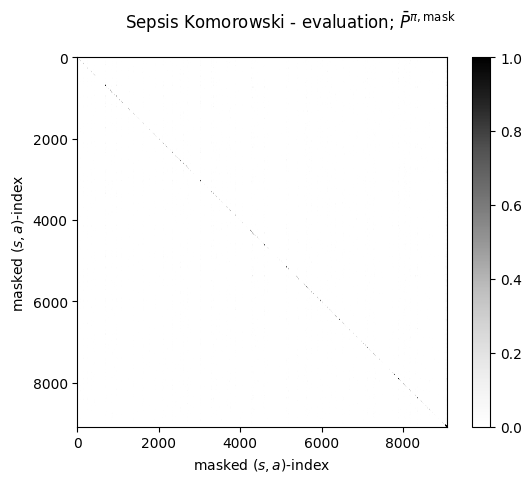

# ---------------------------------------------------------------- # 



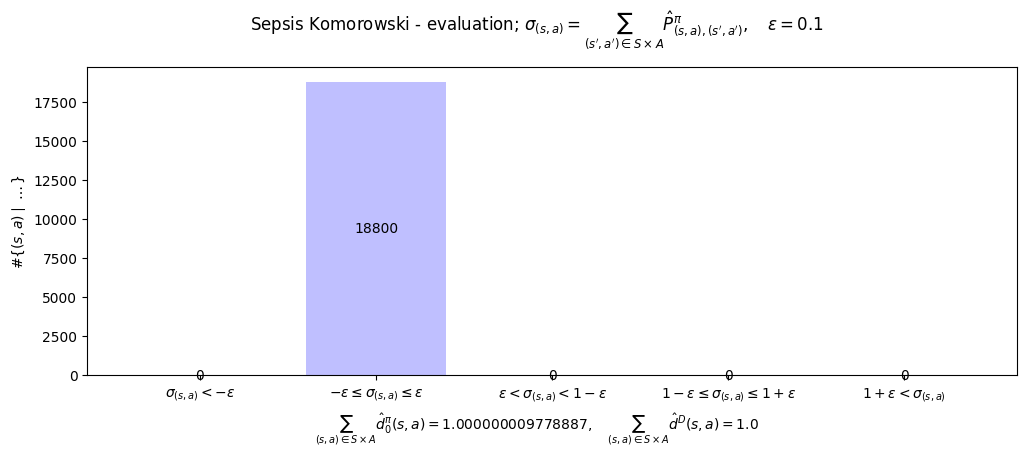

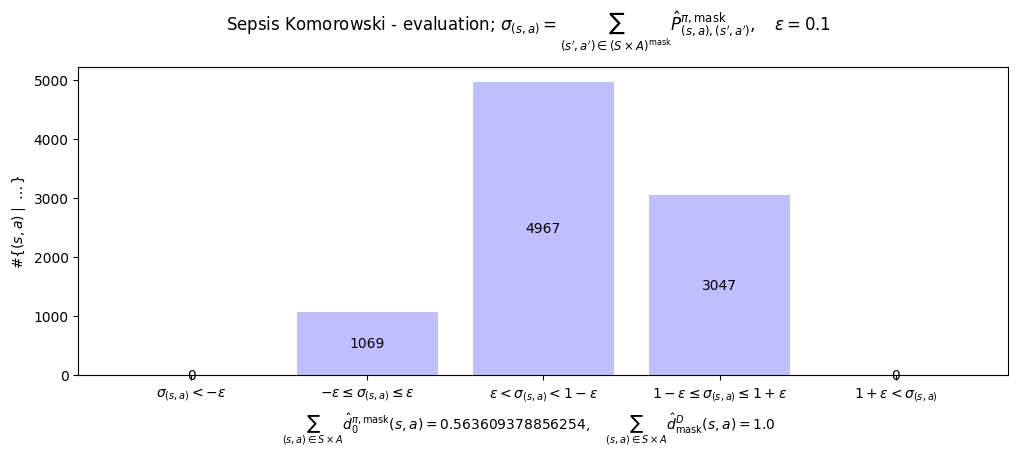

# ---------------------------------------------------------------- # 



In [38]:
test_auxiliary_estimates_sepsis_komorowski("evaluation")

## Deterministic vs. Stochastic

In [ ]:
def is_nearly_deterministic(probs, lower, upper):
    return np.all( np.logical_or(probs <= lower, upper <= probs) )


not_nearly_deterministic_states = {
    "evaluation": set(),
    "behavior": set(),
}

entropies = {
    "evaluation": {},
    "behavior": {},
}

for i in tqdm( range( len(split) ) ):

    lower = 0.0005
    upper = 0.99

    if not is_nearly_deterministic(split.loc[i, "model_probs"], lower, upper):
        not_nearly_deterministic_states["evaluation"].add(split.loc[i, "state"])

    lower = 0.1
    upper = 0.9

    if not is_nearly_deterministic(split.loc[i, "phys_probs"], lower, upper):
        not_nearly_deterministic_states["behavior"].add(split.loc[i, "state"])

    entropies["evaluation"][ split.loc[i, "state"] ] = entropy(split.loc[i, "model_probs"])
    entropies["behavior"]  [ split.loc[i, "state"] ] = entropy(split.loc[i, "phys_probs"])

100%|██████████| 145142/145142 [00:32<00:00, 4442.72it/s]


In [ ]:
for k, v in not_nearly_deterministic_states.items():
    print(f"{k}: {len(v)}")

evaluation: 2
behavior: 712


In [ ]:
for k, v in entropies.items():
    print(k)
    E = [ e for obs, e in v.items() if obs not in absorbing_states ]
    for name, f in zip(["min", "max", "mean", "std"], [np.min, np.max, np.mean, np.max]):
        print(f"{name}: {f(E)}")
    print()

evaluation
min: 0.08778207378042324
max: 0.08778207378042324
mean: 0.08778207378042324
std: 0.08778207378042324

behavior
min: 0.08778207229636009
max: 2.9448769146704388
mean: 1.7385387568247976
std: 2.9448769146704388



In [ ]:
entropy(np.ones(n_act) / n_act)

3.2188758248682

## Quick Evaluation

In [ ]:
def evaluate_all(gamma):
    title = f"{gamma=}"
    print(title)
    print("-"*len(title))

    pvs = {}

    pvs["OnPE behavior"] = estimators["behavior"]["OnPE"](gamma, scale=False)

    for k, b in zip(["SIS", "WIS"], [False, True]):
        pvs[k] = estimators["evaluation"][k](gamma, scale=False)

    if gamma < 1:
        for weighted in [False, True]:
            for kind in kinds:
                pvs[f"DICE ({weighted=}, {kind=})"] = estimators[kind]["TabularDice"].solve(
                    gamma, projected=True, modified=True, weighted=weighted)[0] / (1 - gamma)

    print( pd.Series(pvs) )

In [ ]:
evaluate_all(gamma=0.9999)

gamma=0.9999
------------
OnPE behavior                                 75.814552
SIS                                            0.113323
WIS                                           99.752834
DICE (weighted=False, kind='behavior')      1849.232891
DICE (weighted=False, kind='evaluation')    2885.481165
DICE (weighted=True, kind='behavior')         54.037760
DICE (weighted=True, kind='evaluation')        4.275508
dtype: float64


In [ ]:
evaluate_all(gamma=1.0)

gamma=1.0
---------
OnPE behavior    75.885233
SIS               0.113478
WIS              99.889131
dtype: float64


## Filter Trajectories

In [ ]:
def get_ids_filtered_by_IS_weights_prod(
        dataset, IS_weights_prod,
        lower=-float("inf"), upper=float("inf"),
    ):
    return np.array([
        id
            for id, IS_weight_prod in zip(dataset["id"].unique(), IS_weights_prod)
            if lower <= IS_weight_prod <= upper
    ])

def get_IS_filtered(gamma, lower, upper, verbosity=1):

    print(f"filtering trajectories for IS_weight_prods within [{lower}, {upper}]")
    ids_filtered = get_ids_filtered_by_IS_weights_prod(
        dataset["evaluation"], IS_weights_prod,
        lower=lower, upper=upper, )

    if verbosity >= 1:
        a = ids_filtered.size
        b = dataset["evaluation"]["id"].unique().size
        print(f"only using {a / b} of trajectories")
        print(f"deleting {b - a} trajectories")

    l = IS_weights_prod >= lower
    u = IS_weights_prod <= upper

    if verbosity >= 2:
        plot_histogram(
            data=IS_weights_prod[l * u], bins=100,
            suptitle=f"RRT MIMIC - policy ratio products filtered in [{lower}, {upper}]",
            xlabel="policy ratio products",
            xscale=True, yscale=True,
        )

    if verbosity >= 0:
        f = dataset["evaluation"]["id"].isin(ids_filtered)
        estimator_OnPE = get_get_policy_value(dataset["evaluation"][f])
        estimators_IS = get_estimators_IS(dataset["evaluation"][f], IS_weights[f])

        print( "OnPE behavior:", estimator_OnPE(gamma, scale=False) )
        print( "SIS:", estimators_IS[False](gamma, scale=False) )
        print( "WIS:", estimators_IS[True] (gamma, scale=False) )

In [ ]:
for upper in [float("inf"), 0.01]:
    print("\n", "#", "-"*64, "#", "\n")
    get_IS_filtered(1.0, -float("inf"), upper)


 # ---------------------------------------------------------------- # 

filtering trajectories for IS_weight_prods within [-inf, inf]
only using 1.0 of trajectories
deleting 0 trajectories
OnPE behavior: 75.88523283616077
SIS: 0.1134780263223366
WIS: 99.88913113236016

 # ---------------------------------------------------------------- # 

filtering trajectories for IS_weight_prods within [-inf, 0.01]
only using 0.9993168621200046 of trajectories
deleting 6 trajectories
OnPE behavior: 75.86874786373477
SIS: 0.00016226595688871654
WIS: 56.283033663622405


## FQE

In [ ]:
dataset_d3rlpy = convert_dataset(dataset["evaluation"])


2025-03-18 16:03.06 [info     ] Signatures have been automatically determined. action_signature=Signature(dtype=[dtype('int64')], shape=[(1,)]) observation_signature=Signature(dtype=[dtype('int64')], shape=[(1,)]) reward_signature=Signature(dtype=[dtype('int64')], shape=[(1,)])
2025-03-18 16:03.06 [info     ] Action-space has been automatically determined. action_space=<ActionSpace.DISCRETE: 2>
2025-03-18 16:03.06 [info     ] Action size has been automatically determined. action_size=25


In [ ]:
for i, episode in enumerate(dataset_d3rlpy.episodes):
    print(i)
    print("obs:", np.squeeze(episode.observations))
    print("act:", np.squeeze(episode.actions))
    print("rew:", np.squeeze(episode.rewards))
    print()

0
obs: [135  95 317 317 317 317 298 399 298 148 428 428 144 148 428 750]
act: [ 0 20 20 20 16 11 11 16  1  1  0  0  0  0  0 13]
rew: [   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0 -100]

1
obs: [146 136 470 588 273  55 588 751]
act: [23 23  0  0  0  0  0 17]
rew: [  0   0   0   0   0   0   0 100]

2
obs: [  3   3   3   3   3   3   3   3   3   3   3   3 751]
act: [ 0  0  0  0  0  0  0  0  0  0  0  0 15]
rew: [  0   0   0   0   0   0   0   0   0   0   0   0 100]

3
obs: [545 147 147 545 147 147 147 147 147 750]
act: [ 0  0  0  0  0  0  0  0  0 13]
rew: [   0    0    0    0    0    0    0    0    0 -100]

4
obs: [668 128 136 136 136  25 680 688 610  46 472 472 171  46 642  25 669 507
 374 751]
act: [20 20 15 15 15 19 24 15 15 20 20 15 15 15 15 15  5  5  5 10]
rew: [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0 100]

5
obs: [ 92 365 577  27 130 405 405 130 675 340 340 751]
act: [10 10 10  0  0  0  0  0  0  0  0 16]
rew: [  0   0 

In [ ]:
import torch

class Policy:

    def __init__(self, dataset, n_obs, n_act):
        self.dataset = dataset
        self.n_obs = n_obs
        self.n_act = n_act

        self.probs = -np.ones([n_obs, n_act])
        self.indices = {}

        for i in range( len(dataset) ):
            obs = int( dataset.loc[i, "obs"] )
            probs = dataset.loc[i, "probs"]

            if np.all(self.probs[obs] == -1):
                self.probs[obs] = probs
                self.indices[obs] = i
            else:
                assert np.all(self.probs[obs] == probs), ( self.indices[obs], i )

    @property
    def impl(self):
        return self

    def predict_best_action(self, observation):
        observation = self.preprocess_obs(observation)
        action = np.argmax(self.probs[observation], axis=-1)
        return torch.tensor(action)

    def sample_action(self, observation):
        observation = self.preprocess_obs(observation)
        action = np.array([
            np.random.choice( range(self.n_act), p=self.probs[obs] )
                for obs in observation
        ])
        return torch.tensor(action)

    def preprocess_obs(self, obs):
        obs = np.array(obs, dtype=np.int64)
        obs = np.squeeze(obs)
        return obs


policy = Policy(dataset["evaluation"], n_obs, n_act)

In [ ]:
from d3rlpy.ope import DiscreteFQE
from d3rlpy.ope import FQEConfig

In [ ]:
gamma = 0.9999

In [ ]:
discrete_FQE = DiscreteFQE(algo=policy, config=FQEConfig(gamma=gamma))
discrete_FQE.fit(dataset_d3rlpy, n_steps=1_000_000)

2025-03-18 16:12.36 [info     ] dataset info                   dataset_info=DatasetInfo(observation_signature=Signature(dtype=[dtype('int64')], shape=[(1,)]), action_signature=Signature(dtype=[dtype('int64')], shape=[(1,)]), reward_signature=Signature(dtype=[dtype('int64')], shape=[(1,)]), action_space=<ActionSpace.DISCRETE: 2>, action_size=25)
2025-03-18 16:12.36 [debug    ] Building models...            
2025-03-18 16:12.36 [debug    ] Models have been built.       
2025-03-18 16:12.36 [info     ] Directory is created at d3rlpy_logs/DiscreteFQE_20250318161236
2025-03-18 16:12.36 [info     ] Parameters                     params={'observation_shape': [1], 'action_size': 25, 'config': {'type': 'fqe', 'params': {'batch_size': 100, 'gamma': 0.9999, 'observation_scaler': {'type': 'none', 'params': {}}, 'action_scaler': {'type': 'none', 'params': {}}, 'reward_scaler': {'type': 'none', 'params': {}}, 'compile_graph': False, 'learning_rate': 0.0001, 'optim_factory': {'type': 'adam', 'params'

Epoch 1/100: 100%|██████████| 10000/10000 [00:16<00:00, 599.66it/s, loss=22.8]

2025-03-18 16:12.52 [info     ] DiscreteFQE_20250318161236: epoch=1 step=10000 epoch=1 metrics={'time_sample_batch': 0.0006945683956146241, 'time_algorithm_update': 0.0009143831968307496, 'loss': 22.77044477586746, 'time_step': 0.0016609711408615113} step=10000
2025-03-18 16:12.52 [info     ] Model parameters are saved to d3rlpy_logs/DiscreteFQE_20250318161236/model_10000.d3



Epoch 2/100: 100%|██████████| 10000/10000 [00:16<00:00, 590.16it/s, loss=16.6]

2025-03-18 16:13.09 [info     ] DiscreteFQE_20250318161236: epoch=2 step=20000 epoch=2 metrics={'time_sample_batch': 0.0007003031969070435, 'time_algorithm_update': 0.0009355867862701416, 'loss': 16.55996621899605, 'time_step': 0.0016875968217849732} step=20000
2025-03-18 16:13.09 [info     ] Model parameters are saved to d3rlpy_logs/DiscreteFQE_20250318161236/model_20000.d3


...


Epoch 99/100: 100%|██████████| 10000/10000 [00:16<00:00, 619.41it/s, loss=4.18]

2025-03-18 16:40.06 [info     ] DiscreteFQE_20250318161236: epoch=99 step=990000 epoch=99 metrics={'time_sample_batch': 0.0006708126068115235, 'time_algorithm_update': 0.0008934460639953613, 'loss': 4.181409913707431, 'time_step': 0.0016086580514907836} step=990000
2025-03-18 16:40.06 [info     ] Model parameters are saved to d3rlpy_logs/DiscreteFQE_20250318161236/model_990000.d3



Epoch 100/100: 100%|██████████| 10000/10000 [00:16<00:00, 606.96it/s, loss=4.13]

2025-03-18 16:40.22 [info     ] DiscreteFQE_20250318161236: epoch=100 step=1000000 epoch=100 metrics={'time_sample_batch': 0.0006766712427139283, 'time_algorithm_update': 0.0009165024042129517, 'loss': 4.134311879419163, 'time_step': 0.0016415366888046265} step=1000000
2025-03-18 16:40.22 [info     ] Model parameters are saved to d3rlpy_logs/DiscreteFQE_20250318161236/model_1000000.d3


[(1,
  {'time_sample_batch': 0.0006945683956146241,
   'time_algorithm_update': 0.0009143831968307496,
   'loss': 22.77044477586746,
   'time_step': 0.0016609711408615113}),
 (2,
  {'time_sample_batch': 0.0007003031969070435,
   'time_algorithm_update': 0.0009355867862701416,
   'loss': 16.55996621899605,
   'time_step': 0.0016875968217849732}),
 (3,
  {'time_sample_batch': 0.0006941417455673218,
   'time_algorithm_update': 0.0009739304304122925,
   'loss': 8.438935458600522,
   'time_step': 0.0017196290016174317}),
 (4,
  {'time_sample_batch': 0.0006531312942504883,
   'time_algorithm_update': 0.0008457770109176636,
   'loss': 5.159983677601814,
   'time_step': 0.0015394967317581176}),
 (5,
  {'time_sample_batch': 0.0006666638135910034,
   'time_algorithm_update': 0.0008811722755432129,
   'loss': 4.632303006926924,
   'time_step': 0.0015914408922195434}),
 (6,
  {'time_sample_batch': 0.0006732338190078735,
   'time_algorithm_update': 0.0009041188478469849,
   'loss': 4.47517107831519

In [ ]:
df = dataset["evaluation"]

E_Q = 0

for i in range( len(df) ):
    if df.loc[i, "t"] != 0: continue

    obs = df.loc[i, "obs"]; obs = np.array([[obs]])
    act = np.arange(n_act); act = np.expand_dims(act, axis=-1)

    values = discrete_FQE.predict_value(obs, act)
    probs = df.loc[i, "probs"]

    E_Q += np.dot(probs, values)

E_Q /= np.sum(df["t"] == 0)
rho_hat = (1 - gamma) * E_Q

In [ ]:
E_Q

99.40113321538985

In [ ]:
rho_hat

0.00994011332153789

## `TabularSarsa`

### Prepare

In [17]:
gamma = 0.99

In [18]:
def get_get_metrics(Q_hat_VAFE, rho_hat_VAFE):
    def get_metrics(Q_hat, rho_hat):
        metrics = {
            "pv": rho_hat,
            "pv_error": np.abs(rho_hat - rho_hat_VAFE),
            "vaf_L2_error": np.mean( np.abs(Q_hat - Q_hat_VAFE) ** 2 )
        }
        return metrics

    return get_metrics

In [19]:
latex_gamma = r"\gamma"
latex_rho_hat = r"\hat \rho^\pi(\gamma)"
latex_rho_hat_VAFE  = r"\hat \rho^\pi_\text{VAFE}(\gamma)"
latex_rho_hat_Error  = f"|{latex_rho_hat} - {latex_rho_hat_VAFE}|"
latex_Q_MSE = r"\hat{\mathbb{E}} | \hat Q^\pi - \hat Q^\pi_\text{VAFE} |^2"

latex_scale = lambda x: x + r" \div (1 - \gamma)"
latex_dollar = lambda x: f"${x}$"

In [26]:
def plot_SARSA(kind, y, ylabel, title_post_fix):

    w = 10_000
    x = np.arange(len(y))
    y_ma = moving_average_N(y, w)

    plt.plot(x, y, color="blue", alpha=0.1)
    plt.plot(x[w-1:], y_ma, color="blue", label="TabularSarsa, alpha=0.1")

    # plt.ylim([0, 5])

    title = f"Sepsis Komorowski - {kind} - {title_post_fix}" + "\n" + "gamma=0.99"

    plt.xlabel("step")
    plt.ylabel(ylabel)
    plt.grid(linestyle=":")
    plt.title(title)
    plt.legend()
    plt.tight_layout()

    file_name = title.replace("\n", "; ")
    plt.savefig( os.path.join(dir_images, f"{file_name}.png") )

    plt.show()

In [21]:
def load_metrics(metrics_keys, dir_load, hyperparameters):
    id = json_get_id(
        file_path=os.path.join(dir_load, "evaluation.json"),
        dictionary=hyperparameters,
    )
    assert id is not None

    metrics = {}
    for k in metrics_keys:
        file = os.path.join(dir_load, id, f"{k}.npy")
        v = np.load(file)
        metrics[k] = v

    return metrics

### `behavior`

In [22]:
tabular_sarsa_behavior = TabularSarsa(dataset["behavior"], n_obs, n_act)

In [23]:
rho_hat_VAFE_behavior, info_VAFE_behavior = estimators["behavior"]["TabularVafe"].solve(gamma, projected=True)
Q_VAFE_behavior = info_VAFE_behavior["Q_hat"]
get_metrics_behavior = get_get_metrics(Q_VAFE_behavior, rho_hat_VAFE_behavior)

In [ ]:
rho_hat_SARSA_behavior, info_SARSA_behavior = tabular_sarsa_behavior.solve(
    gamma=gamma,
    n_epochs=64, by="episodes", alpha=0.1, shuffle=False, verbosity=2, get_metrics=get_metrics_behavior, dir_save=os.path.join(dir_data, "behavior"),
)

epoch 1/64


100%|██████████| 11967/11967 [03:16<00:00, 61.04it/s, pv=0.132, pv_error=0.214, vaf_L2_error=509]


epoch 2/64


100%|██████████| 11967/11967 [03:14<00:00, 61.51it/s, pv=0.174, pv_error=0.173, vaf_L2_error=399]


epoch 3/64


...

100%|██████████| 11967/11967 [02:49<00:00, 70.57it/s, pv=0.347, pv_error=0.000387, vaf_L2_error=3.94]


epoch 63/64


100%|██████████| 11967/11967 [02:51<00:00, 69.85it/s, pv=0.347, pv_error=0.000439, vaf_L2_error=3.94]


epoch 64/64


100%|██████████| 11967/11967 [02:43<00:00, 73.13it/s, pv=0.347, pv_error=0.000487, vaf_L2_error=3.94]


In [22]:
metrics_SARSA_behavior_reloaded = load_metrics(
    metrics_keys=["pv", "pv_error", "vaf_L2_error"],
    dir_load=os.path.join(dir_data, "behavior"),
    hyperparameters={
        "name": "TabularSarsa",
        "gamma": gamma,
        "seed": None,
        "n_steps": None,
        "n_epochs": 64,
        "by": "episodes",
        "alpha": 0.1,
        "shuffle": False,
    }
)

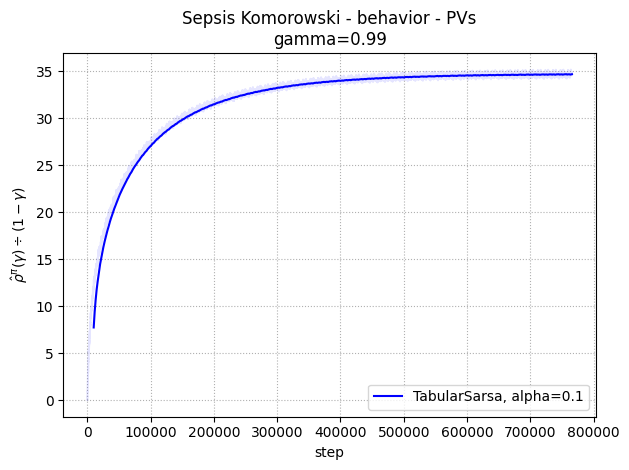

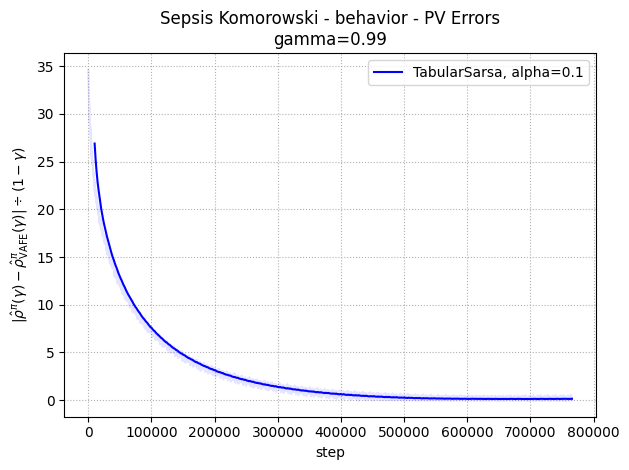

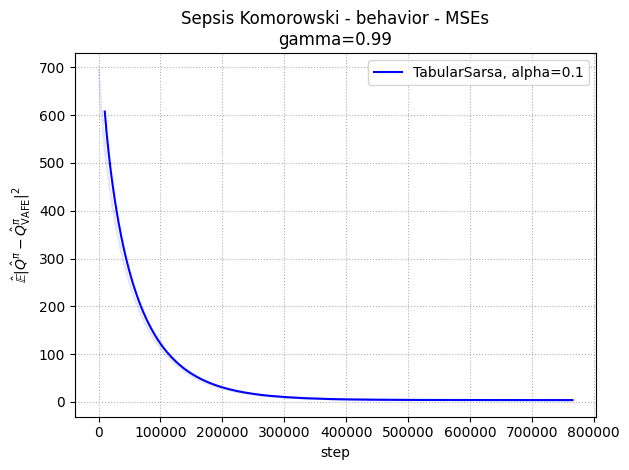

In [27]:
plot_SARSA(
    kind="behavior",
    y=metrics_SARSA_behavior_reloaded["pv"] / (1 - gamma),
    title_post_fix="PVs",
    ylabel=latex_dollar(latex_scale(latex_rho_hat)),
)
plot_SARSA(
    kind="behavior",
    y=metrics_SARSA_behavior_reloaded["pv_error"] / (1 - gamma),
    title_post_fix="PV Errors",
    ylabel=latex_dollar(latex_scale(latex_rho_hat_Error)),
)
plot_SARSA(
    kind="behavior",
    y=metrics_SARSA_behavior_reloaded["vaf_L2_error"],
    title_post_fix="MSEs",
    ylabel=latex_dollar(latex_Q_MSE),
)

### `evaluation`

In [23]:
tabular_sarsa_evaluation = TabularSarsa(dataset["evaluation"], n_obs, n_act)

In [24]:
rho_hat_VAFE_evaluation, info_VAFE_evaluation = estimators["evaluation"]["TabularVafe"].solve(gamma, projected=True)
Q_VAFE_evaluation = info_VAFE_evaluation["Q_hat"]
get_metrics_evaluation = get_get_metrics(Q_VAFE_evaluation, rho_hat_VAFE_evaluation)

In [25]:
rho_hat_SARSA_evaluation, info_SARSA_evaluation = tabular_sarsa_evaluation.solve(
    gamma=gamma,
    n_epochs=64, by="episodes", alpha=0.1, shuffle=False, verbosity=2, get_metrics=get_metrics_evaluation, dir_save=os.path.join(dir_data, "evaluation"),
)

epoch 1/64


100%|██████████| 11967/11967 [03:32<00:00, 56.28it/s, pv=0.0105, pv_error=0.053, vaf_L2_error=226]  


epoch 2/64


100%|██████████| 11967/11967 [03:32<00:00, 56.36it/s, pv=0.0143, pv_error=0.0492, vaf_L2_error=195]


epoch 3/64


...

100%|██████████| 11967/11967 [03:08<00:00, 63.45it/s, pv=0.0561, pv_error=0.00736, vaf_L2_error=6.05]


epoch 63/64


100%|██████████| 11967/11967 [03:10<00:00, 62.71it/s, pv=0.0562, pv_error=0.00731, vaf_L2_error=6.03]


epoch 64/64


100%|██████████| 11967/11967 [03:11<00:00, 62.39it/s, pv=0.0562, pv_error=0.00726, vaf_L2_error=6.02]


In [28]:
metrics_SARSA_evaluation_reloaded = load_metrics(
    metrics_keys=["pv", "pv_error", "vaf_L2_error"],
    dir_load=os.path.join(dir_data, "evaluation"),
    hyperparameters={
        "name": "TabularSarsa",
        "gamma": gamma,
        "seed": None,
        "n_steps": None,
        "n_epochs": 64,
        "by": "episodes",
        "alpha": 0.1,
        "shuffle": False,
    }
)

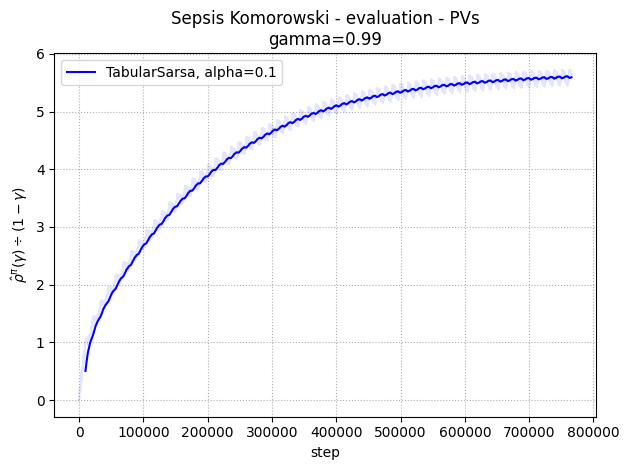

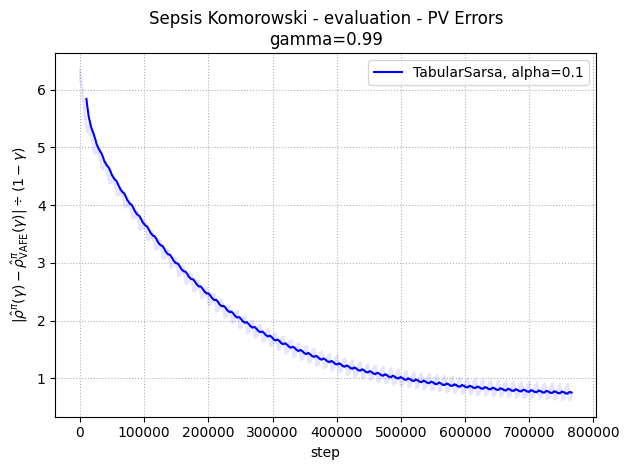

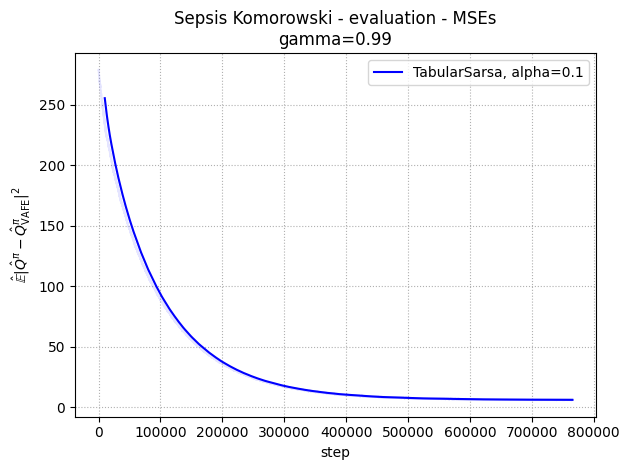

In [29]:
plot_SARSA(
    kind="evaluation",
    y=metrics_SARSA_evaluation_reloaded["pv"] / (1 - gamma),
    title_post_fix="PVs",
    ylabel=latex_dollar(latex_scale(latex_rho_hat)),
)
plot_SARSA(
    kind="evaluation",
    y=metrics_SARSA_evaluation_reloaded["pv_error"] / (1 - gamma),
    title_post_fix="PV Errors",
    ylabel=latex_dollar(latex_scale(latex_rho_hat_Error)),
)
plot_SARSA(
    kind="evaluation",
    y=metrics_SARSA_evaluation_reloaded["vaf_L2_error"],
    title_post_fix="MSEs",
    ylabel=latex_dollar(latex_Q_MSE),
)